In [1]:
%pip install -q python-terrier matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Imports + init PyTerrier

In [2]:
import json
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyterrier as pt

if not pt.started():
    pt.init()

C:\Users\User\AppData\Local\Temp\ipykernel_29444\1827828821.py:10: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():
Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
C:\Users\User\AppData\Local\Temp\ipykernel_29444\1827828821.py:11: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


 Charger la collection tweets

In [3]:
tweets_path = Path("tweets.jsonl")

docs = []
with tweets_path.open("r", encoding="utf-8") as f:
    for line in f:
        x = json.loads(line)
        docs.append({
            "docno": str(x["docno"]),
            "text": x.get("text", "") or "",
            "url": x.get("url", "") or "",
            "source": x.get("source", "") or "",
        })

docs_df = pd.DataFrame(docs)
print("Nb docs:", len(docs_df))
docs_df.head(3)

Nb docs: 500


,docno,text,url,source
0,3fcdb9735ec81d75,Iran has escaped collapse and regime change. U...,https://x.com/AkdKli/status/2045167048649507046,x.com
1,f5db3a28381e9607,This is a surgical dismantling of of a murder...,https://x.com/neurowaxx/status/204516367424383...,x.com
2,a5d3b15df7b31ca7,Netanyahu’s gambling that the Iran regime will...,https://x.com/Livelongandpr18/status/204516344...,x.com


Charger les requêtes depuis topics.xml

In [4]:
topics_path = Path("topics.xml")
root = ET.parse(topics_path).getroot()

topics = []
for topic in root.findall("topic"):
    qid = topic.attrib["number"].strip()
    query = topic.find("query").text.strip()
    topics.append({"qid": qid, "query": query})

topics_df = pd.DataFrame(topics)
print("Nb requêtes:", len(topics_df))
topics_df

Nb requêtes: 5


,qid,query
0,Q1,Iran regime collapse
1,Q2,Hormuz strait closure
2,Q3,Revolutionary Guard attack
3,Q4,Iran supreme leader speech
4,Q5,US bases Iran missiles


 Charger qrels.txt (format TREC)

In [5]:
qrels_path = Path("qrels.txt")

qrels_df = pd.read_csv(
    qrels_path,
    sep=r"\s+",
    header=None,
    names=["qid", "Q0", "docno", "label"],
    dtype={"qid": str, "Q0": str, "docno": str, "label": int},
)[["qid", "docno", "label"]]

print("Nb qrels:", len(qrels_df))
qrels_df.head(5)

Nb qrels: 500


,qid,docno,label
0,Q1,3fcdb9735ec81d75,1
1,Q1,f5db3a28381e9607,1
2,Q1,a5d3b15df7b31ca7,1
3,Q1,fbfdd0aee2d88a35,1
4,Q1,5be6f42915ac8782,1


Indexation + choix des termes
Ici on choisit une indexation classique Terrier avec normalisation, stopwords et stemming Porter.

In [6]:
from pathlib import Path

# Evite le double préfixe var/var en passant un chemin absolu
index_dir = (Path.cwd() / "index" / "pyterrier_tweets").resolve()
index_dir.mkdir(parents=True, exist_ok=True)

indexer = pt.IterDictIndexer(
    str(index_dir),
    overwrite=True,
    meta={"docno": 32, "url": 256, "source": 64},
    stemmer="porter",
    stopwords="terrier",
)

indexref = indexer.index(docs_df.to_dict(orient="records"))
print("Index créé:", indexref)

index = pt.IndexFactory.of(indexref)
print(index.getCollectionStatistics().toString())

19:21:42.126 [main] ERROR org.terrier.structures.indexing.Indexer -- Could not rename index
java.io.IOException: Rename of index structure file 'C:\Users\User\Desktop\SRI\index\pyterrier_tweets/data_1.direct.bf' (exists) to 'C:\Users\User\Desktop\SRI\index\pyterrier_tweets/data.direct.bf' (exists) failed - likely that source file is still open. Possible indexing bug?
	at org.terrier.structures.IndexUtil.renameIndex(IndexUtil.java:379)
	at org.terrier.structures.indexing.Indexer.index(Indexer.java:388)
Index créé: <org.terrier.querying.IndexRef at 0x22351f73f70 jclass=org/terrier/querying/IndexRef jself=<LocalRef obj=0x29148b7a at 0x2232a89a950>>
Number of documents: 500
Number of terms: 2575
Number of postings: 10838
Number of fields: 0
Number of tokens: 11765
Field names: []
Positions:   false



Extraction des termes d’indexation

In [7]:
index = pt.IndexFactory.of(indexref)
lexicon = index.getLexicon()

it = lexicon.iterator()
rows = []
for _ in range(100):
    if not it.hasNext():
        break
    kv = it.next()
    term = kv.getKey()
    entry = kv.getValue()
    rows.append({
        "term": term,
        "df": int(entry.getDocumentFrequency()),
        "cf": int(entry.getFrequency()),
    })

terms_df = pd.DataFrame(rows)
terms_df.head(20)

,term,df,cf
0,000,6,6
1,04,1,1
2,1,14,14
3,10,8,10
4,100,7,7
5,1000,1,3
6,10am,1,1
7,10b,1,1
8,11,2,2
9,110,1,1


In [8]:
# lecture complète du lexique (peut être un peu long selon la taille)
it = lexicon.iterator()
all_terms = []
while it.hasNext():
    kv = it.next()
    term = kv.getKey()
    entry = kv.getValue()
    all_terms.append({
        "term": term,
        "df": int(entry.getDocumentFrequency()),
        "cf": int(entry.getFrequency()),
    })

all_terms_df = pd.DataFrame(all_terms)
all_terms_df.sort_values("cf", ascending=False).head(30)

,term,df,cf
1213,iran,395,534
255,attack,136,161
1095,hormuz,140,159
1885,regim,120,158
2185,strait,137,156
1487,missil,120,135
1215,iranian,113,124
293,base,106,122
2515,will,88,116
502,collaps,103,110


## Recherche des tweets pertinents
L'objectif ici est de retourner les 30 premiers tweets pour chaque requête avec plusieurs modèles de recherche.

In [9]:
retrievers = {
    "BM25": pt.BatchRetrieve(indexref, wmodel="BM25", num_results=30),
    "TF_IDF": pt.BatchRetrieve(indexref, wmodel="TF_IDF", num_results=30),
    "DPH": pt.BatchRetrieve(indexref, wmodel="DPH", num_results=30),
    "PL2": pt.BatchRetrieve(indexref, wmodel="PL2", num_results=30),
    "InL2": pt.BatchRetrieve(indexref, wmodel="InL2", num_results=30),
}

runs = {name: retr.transform(topics_df) for name, retr in retrievers.items()}

for name, run in runs.items():
    print(f"{name}: {len(run)} lignes, {run['qid'].nunique()} requêtes")

bm25_top30_q1 = runs["BM25"].query("qid == 'Q1'")[['qid', 'docno', 'score', 'rank']].head(30)
bm25_top30_q1

C:\Users\User\AppData\Local\Temp\ipykernel_29444\2311922652.py:2: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  "BM25": pt.BatchRetrieve(indexref, wmodel="BM25", num_results=30),
C:\Users\User\AppData\Local\Temp\ipykernel_29444\2311922652.py:3: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  "TF_IDF": pt.BatchRetrieve(indexref, wmodel="TF_IDF", num_results=30),
C:\Users\User\AppData\Local\Temp\ipykernel_29444\2311922652.py:4: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  "DPH": pt.BatchRetrieve(indexref, wmodel="DPH", num_results=30),
C:\Users\User\AppData\Local\Temp\ipykernel_29444\2311922652.py:5: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.1

BM25: 150 lignes, 5 requêtes
TF_IDF: 150 lignes, 5 requêtes
DPH: 150 lignes, 5 requêtes
PL2: 150 lignes, 5 requêtes
InL2: 150 lignes, 5 requêtes


,qid,docno,score,rank
0,Q1,a2193c4052838008,2.951018,0
1,Q1,f5db3a28381e9607,2.692487,1
2,Q1,1c0bb2b2fa2121b8,2.692487,2
3,Q1,782eb9fe28396faa,2.582891,3
4,Q1,bd51c866aaded72d,2.513398,4
5,Q1,31efc8ca23f3043d,2.480977,5
6,Q1,e0a358186114dbb1,2.480977,6
7,Q1,a77df25dafc79883,2.480977,7
8,Q1,501b8de595d9b635,2.480977,8
9,Q1,477f38ee2199b109,2.480977,9


## Évaluation des résultats
Les résultats sont évalués avec MAP, P@1, P@5, P@10, ainsi qu'une analyse rappel-précision.

In [10]:
metrics = ["map", "P_1", "P_5", "P_10", "recall_30"]

exp = pt.Experiment(
    list(retrievers.values()),
    topics_df,
    qrels_df,
    eval_metrics=metrics,
    names=list(retrievers.keys()),
    round=4,
    baseline=0,
    dataframe=True,
    verbose=True,
    filter_by_qrels=False,
    batch_size=32,
    perquery=False,
)

exp

pt.Experiment: 100%|██████████| 5/5 [00:00<00:00, 40.81batches/s]


,name,map,P_1,P_5,P_10,recall_30,map +,map -,map p-value,P_1 +,...,P_1 p-value,P_5 +,P_5 -,P_5 p-value,P_10 +,P_10 -,P_10 p-value,recall_30 +,recall_30 -,recall_30 p-value
0,BM25,0.1454,0.4,0.28,0.38,0.3400,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TF_IDF,0.1603,0.4,0.24,0.28,0.3800,2.0,3.0,0.475793,1.0,...,1.0,0.0,1.0,0.373901,0.0,4.0,0.034109,2.0,2.0,0.373901
2,DPH,0.1558,0.4,0.28,0.22,0.3933,1.0,4.0,0.677667,1.0,...,1.0,1.0,1.0,1.000000,0.0,4.0,0.077742,3.0,0.0,0.120243
3,PL2,0.1667,0.4,0.28,0.26,0.4000,2.0,3.0,0.298868,1.0,...,1.0,1.0,1.0,1.000000,0.0,5.0,0.003883,3.0,1.0,0.194929
4,InL2,0.1693,0.4,0.28,0.30,0.3933,3.0,1.0,0.227419,1.0,...,1.0,1.0,1.0,1.000000,0.0,3.0,0.099301,2.0,0.0,0.195138


## Détail par requête
On observe ici, pour chaque requête, les différences de performance entre modèles.

In [11]:
per_query = pt.Experiment(
    list(retrievers.values()),
    topics_df,
    qrels_df,
    eval_metrics=["map", "P_1", "P_5", "P_10", "recall_30"],
    names=list(retrievers.keys()),
    perquery=True,
    round=4,
    filter_by_qrels=False,
    batch_size=32,
    dataframe=True,
)

per_query.sort_values(["qid", "measure", "value"], ascending=[True, True, False]).head(30)

,name,qid,measure,value
51,DPH,Q1,P_1,1.0000
101,InL2,Q1,P_1,1.0000
76,PL2,Q1,P_1,1.0000
26,TF_IDF,Q1,P_1,1.0000
1,BM25,Q1,P_1,0.0000
3,BM25,Q1,P_10,0.4000
53,DPH,Q1,P_10,0.2000
103,InL2,Q1,P_10,0.2000
78,PL2,Q1,P_10,0.2000
28,TF_IDF,Q1,P_10,0.2000


## Courbes rappel-précision
Cette cellule calcule une courbe rappel-précision interpolée moyenne pour chaque modèle à partir des top 30 résultats retournés.

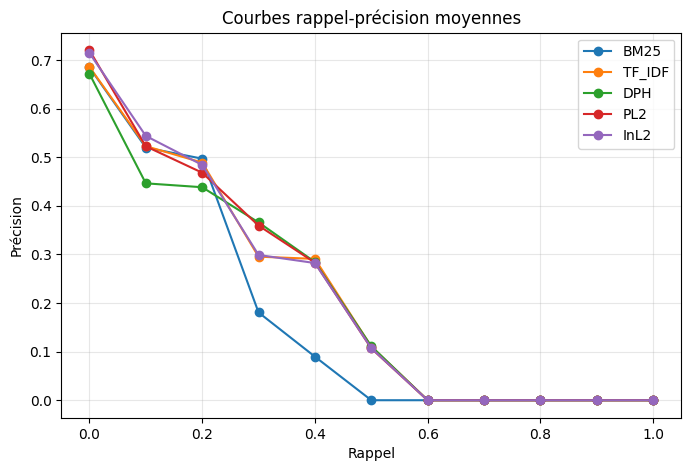

In [12]:
def interpolated_precision_recall(run_df, qrels_df, recall_levels=None):
    if recall_levels is None:
        recall_levels = np.linspace(0, 1, 11)

    qrels_lookup = {
        qid: set(group.loc[group["label"] > 0, "docno"].astype(str))
        for qid, group in qrels_df.groupby("qid")
    }

    curves = []
    for qid, group in run_df.groupby("qid"):
        relevant = qrels_lookup.get(qid, set())
        if not relevant:
            continue

        retrieved = group.sort_values("rank")["docno"].astype(str).tolist()
        hits = 0
        precisions = []
        recalls = []

        for rank, docno in enumerate(retrieved, start=1):
            if docno in relevant:
                hits += 1
            precisions.append(hits / rank)
            recalls.append(hits / len(relevant))

        interpolated = []
        for level in recall_levels:
            candidates = [p for p, r in zip(precisions, recalls) if r >= level]
            interpolated.append(max(candidates) if candidates else 0.0)

        curves.append(interpolated)

    if not curves:
        return pd.DataFrame({"recall": recall_levels, "precision": np.zeros(len(recall_levels))})

    mean_curve = np.mean(np.array(curves), axis=0)
    return pd.DataFrame({"recall": recall_levels, "precision": mean_curve})

plt.figure(figsize=(8, 5))
for name, run in runs.items():
    curve_df = interpolated_precision_recall(run, qrels_df)
    plt.plot(curve_df["recall"], curve_df["precision"], marker="o", label=name)

plt.title("Courbes rappel-précision moyennes")
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Export des résultats
Cette étape sauvegarde les scores globaux, les scores par requête, et les top 30 tweets retournés par chaque modèle.

In [13]:
results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

exp.to_csv(results_dir / "pyterrier_model_comparison.csv", index=False)
per_query.to_csv(results_dir / "pyterrier_per_query.csv", index=False)

for name, run in runs.items():
    run.to_csv(results_dir / f"run_{name.lower()}_top30.csv", index=False)

print("Exports créés dans le dossier results/")

Exports créés dans le dossier results/
